In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import missingno as msno
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/datasets/yeanzc/telco-customer-churn-ibm-dataset/Telco_customer_churn.xlsx


In [2]:
df = pd.read_excel("/kaggle/input/datasets/yeanzc/telco-customer-churn-ibm-dataset/Telco_customer_churn.xlsx")

## Template Business Questions

1. What is the overall churn rate?
2. How does churn vary by tenure?
3. Which contract types have highest churn?
4. Does higher usage (charges) reduce churn?
5. What patterns appear before customers churn?

## Data Overview & Bit of Cleaning

In [3]:
## too much to show
print(df.shape)
display(df.head())


(7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


col_0,0,1
Churn Label,,
No,0,5174
Yes,1869,0


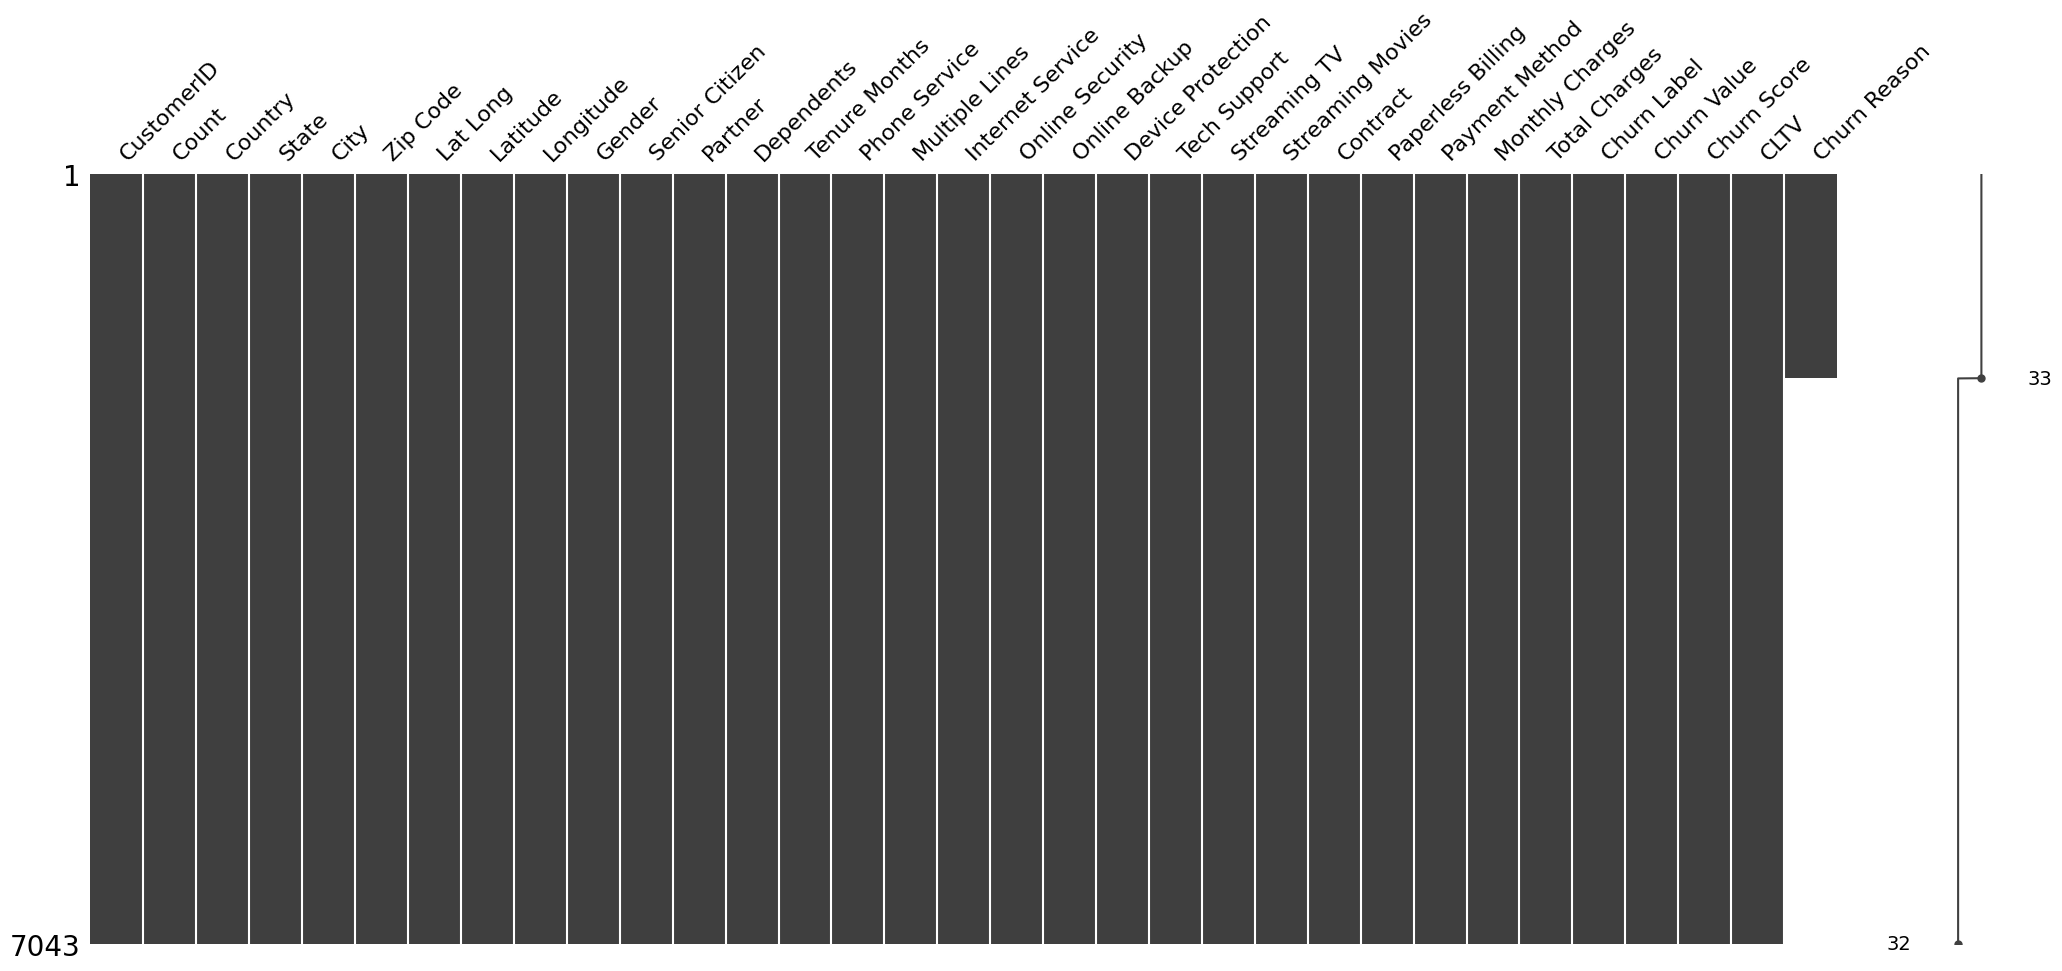

In [4]:
# not really misssing value, just some give no reason for churning. 
# print(df.isnull().sum())
msno.matrix(df)

# eh actually, not really. all churn have a reason. good things.
pd.crosstab(df["Churn Label"], df.isnull().sum(1))

In [5]:
# check the non-object dtypes in summary
display(df.describe(exclude="object"))

# check the object dtypes one by one
display(df.select_dtypes("object").head().transpose())

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


,0,1,2,3,4
CustomerID,3668-QPYBK,9237-HQITU,9305-CDSKC,7892-POOKP,0280-XJGEX
Country,United States,United States,United States,United States,United States
State,California,California,California,California,California
City,Los Angeles,Los Angeles,Los Angeles,Los Angeles,Los Angeles
Lat Long,"33.964131, -118.272783","34.059281, -118.30742","34.048013, -118.293953","34.062125, -118.315709","34.039224, -118.266293"
Gender,Male,Female,Female,Female,Male
Senior Citizen,No,No,No,No,No
Partner,No,No,No,Yes,No
Dependents,No,Yes,Yes,Yes,Yes
Phone Service,Yes,Yes,Yes,Yes,Yes


In [6]:
# change total charges into float.

# fail, couldn't convert ' ' to float
# df["Total Charges"].apply(float) 

df.loc[df["Total Charges"] == " ", "Total Charges"] = "0"
df["Total Charges"] = df["Total Charges"].apply(float)

In [7]:
# check the non-object dtypes in summary #2
display(df.describe(exclude="object"))

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


## Python Solution #1
- churn rate around 26.5 percent
- long time tenure correlated with lower churn rate && from people who churns, most of them having short-tenure months
- the shorter the contract term the higher the churn rate
- from people who churn, mostly have a higher monthly charges & from people who non-churn mostly have a lower monthly charges
- fiber optic internet service with month to month contract has the highest risk of being churned

0.2653698707936959


<Axes: xlabel='Churn Label', ylabel='Tenure Months'>

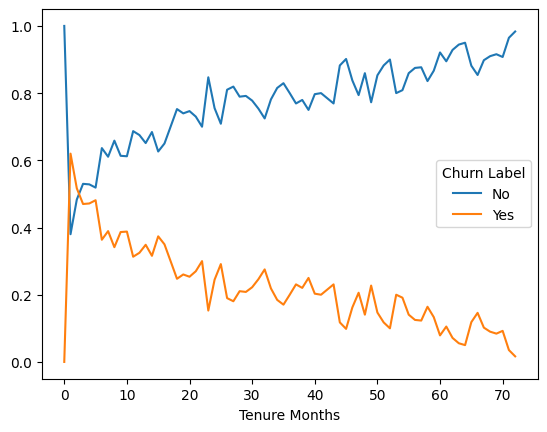

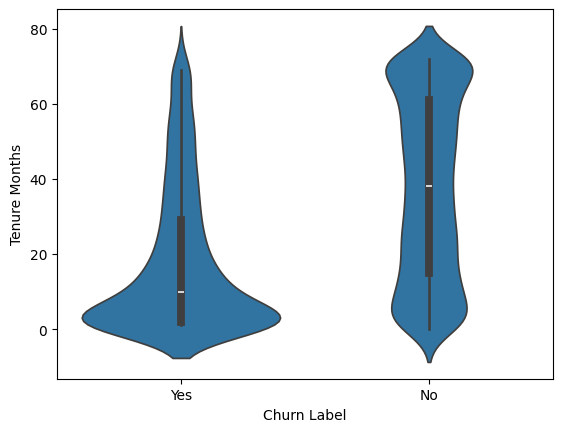

In [9]:
# 1. What is the overall churn rate? 26.5 percent
print(df["Churn Value"].mean())

# 2. How does churn vary by tenure? 

# A. Long time tenure ~ lower churn rate
pd.crosstab(df["Tenure Months"], df["Churn Label"], normalize=0).plot()

# B. Most churn-persons come from short-tenure months
plt.figure()
sns.violinplot(df, x="Churn Label", y="Tenure Months")


<Axes: ylabel='Contract'>

<Figure size 640x480 with 0 Axes>

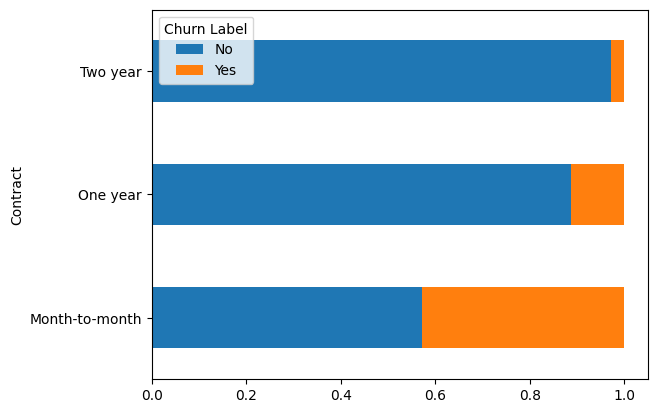

In [10]:
# 3. Which contract types have highest churn? short-term contract ~ higher churn rate
plt.figure()
pd.crosstab(df["Contract"], df['Churn Label'], normalize=0).plot(kind="barh", stacked=True)

<Axes: xlabel='Monthly Charges', ylabel='Density'>

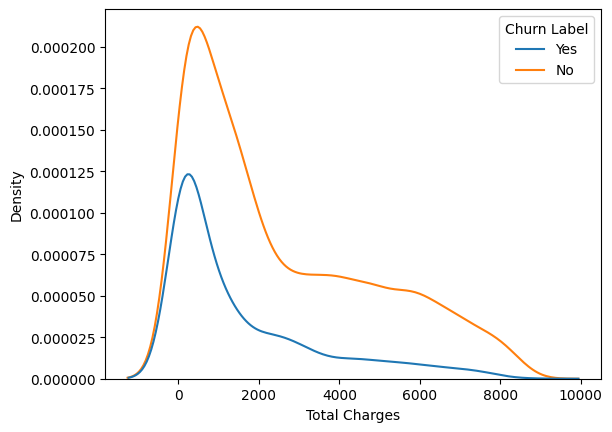

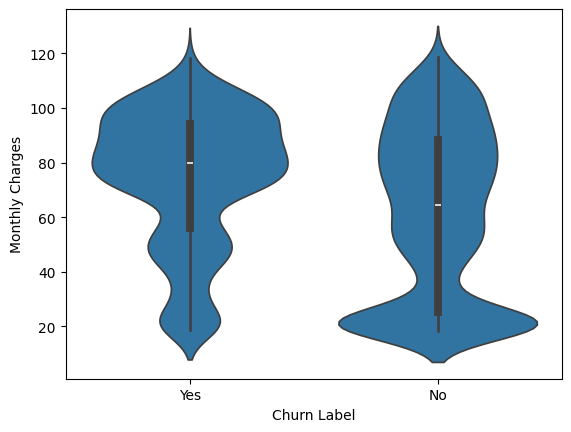

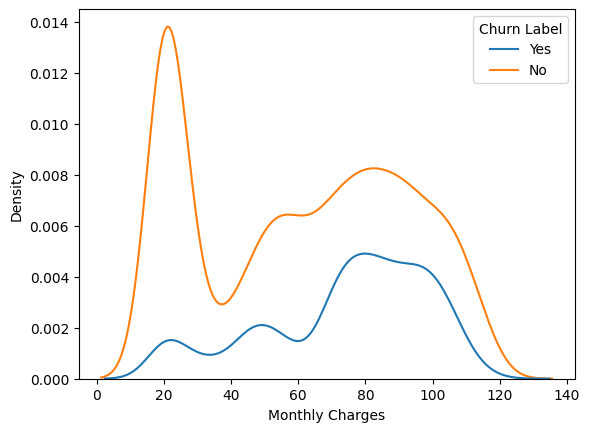

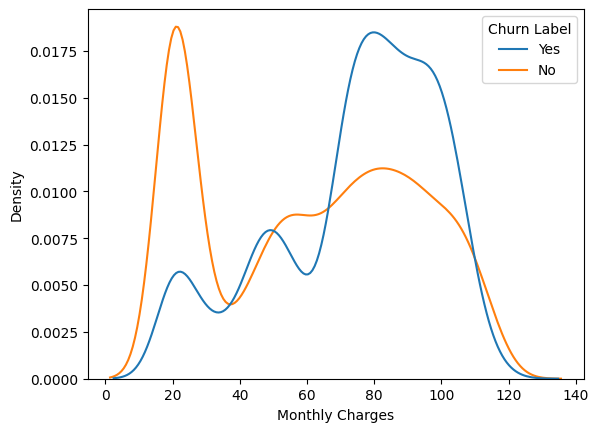

In [11]:
# 4. Does higher usage (charges) reduce churn?
# A. can't really tell tho. 
plt.figure()
sns.kdeplot(df, hue="Churn Label", x="Total Charges")

# A. so from churn-people, mostly have a higher monthly charges and from non-churn, mostly have a lower price
plt.figure()
sns.violinplot(df, x="Churn Label", y="Monthly Charges")

plt.figure()
sns.kdeplot(df, hue="Churn Label", x="Monthly Charges", common_norm=True)

plt.figure()
sns.kdeplot(df, hue="Churn Label", x="Monthly Charges", common_norm=False)

<Axes: xlabel='Yes', ylabel='Contract'>

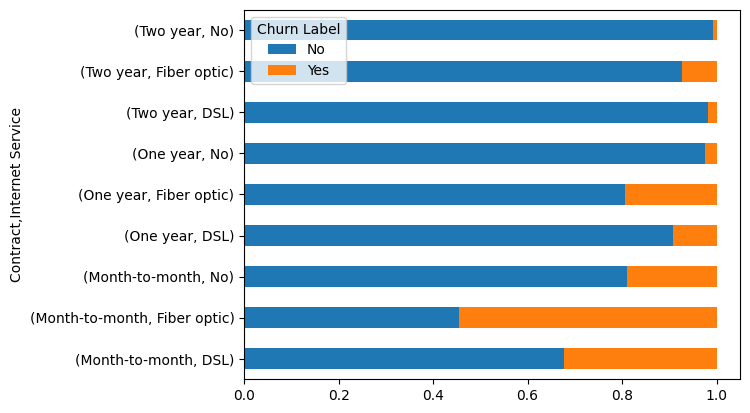

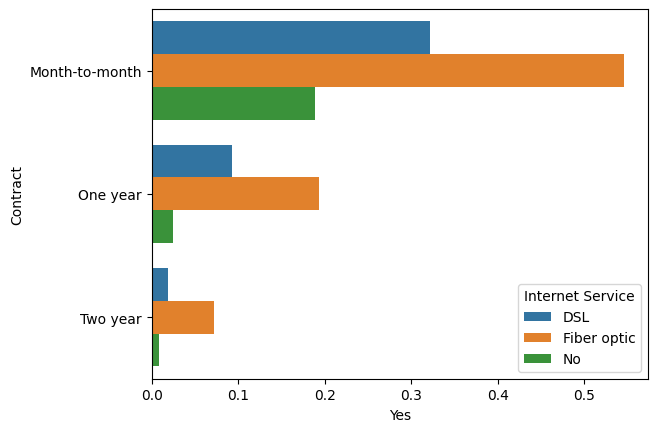

In [12]:
# 5. What patterns appear before customers churn? --> high risk segment? but how do i know which is which? lol.
pd.crosstab(index=[df["Contract"], df["Internet Service"]], columns=df['Churn Label'], normalize=0).plot(kind="barh", stacked=True)

plt.figure()
sns.barplot(pd.crosstab(index=[df["Contract"], df["Internet Service"]], columns=df['Churn Label'], normalize=0).reset_index(), 
            y="Contract", x="Yes", hue="Internet Service")


## Query-ing using SQLite3
Why would i do this? IDK. 

In [13]:
# what, making connection? 
conn = sqlite3.connect(':memory:')
df.to_sql('churn', conn, index=False)

cursor = conn.cursor()

In [14]:
def executor(query:str):
    cursor.execute(query)
    rows = cursor.fetchall()

    for row in rows:
        print(row)
    print("\n")

In [74]:
# 1. What is the overall churn rate?
# 2. How does churn vary by tenure?
# 3. Which contract types have highest churn?
# 4. Does higher usage (charges) reduce churn?
# 5. What patterns appear before customers churn?


# sql queries

q1 = '''
SELECT 
    AVG(`Churn Value`) AS churn_rate
FROM churn;
'''

q2 = '''
SELECT 
    CASE
         WHEN `Tenure Months` < 12 THEN '0-1 year'
         WHEN `Tenure Months` < 24 THEN '1-2 years'
         ELSE '2+ years'
    END AS tenure_group,
    AVG(`Churn Value`) as churn_rate
FROM churn
GROUP BY tenure_group;
'''

q3 = '''
SELECT
    Contract, 
    AVG(`Churn Value`) as churn_rate,
    COUNT(*) AS customers
FROM churn
GROUP BY Contract;
'''

q4 = '''
SELECT 
    CASE 
        WHEN `Monthly Charges` < 30 THEN 'Low'
        WHEN `Monthly Charges` < 70 THEN 'Medium'
        ELSE 'High'
    END AS charge_group,
    AVG(`Churn Value`) AS churn_rate
FROM churn
GROUP BY charge_group;
'''

q5='''
SELECT 
    Contract,
    `Internet Service`,
    AVG(`Churn Value`) AS churn_rate
FROM churn
GROUP BY Contract, `Internet Service`
ORDER BY churn_rate DESC;
'''

In [75]:
# executor("select `Tenure Months` from churn limit 10")

## Result & Alternative Python Solution #2
- churn rate around 26.5 percent
- long time tenure correlated with lower churn rate && from people who churns, most of them having short-tenure months
- the shorter the contract term the higher the churn rate (month-to-month contract has much higher churn rate than 1y/2y)
- from people who churn, mostly have a higher monthly charges & from people who non-churn mostly have a lower monthly charges && higher monthly charges leading to higher churn rate
- fiber optic internet service with month to month contract has the highest risk of being churned

In [21]:
executor(q1)

(0.2653698707936959,)




('0-1 year', 0.4828419526341228)
('1-2 years', 0.29512893982808025)
('2+ years', 0.14285714285714285)




/tmp/ipykernel_55/2519651627.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby("tenure_bin")["Churn Value"].mean())


tenure_bin
0-1    0.482842
1-2    0.295129
2+     0.142857
Name: Churn Value, dtype: float64

<Axes: xlabel='Churn Value', ylabel='tenure_bin'>

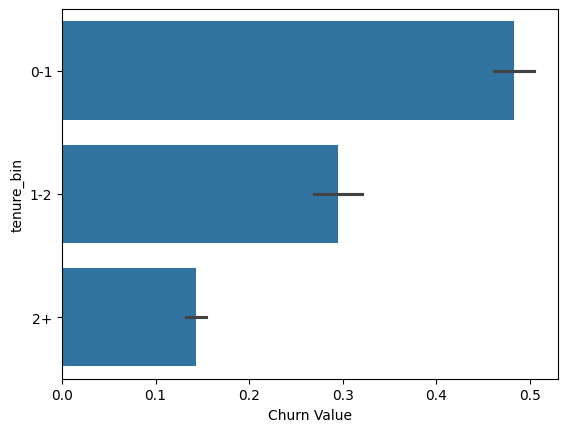

In [68]:
executor(q2)

# long time tenure correlated with lower churn rate
df["tenure_bin"] = pd.cut(df["Tenure Months"], bins=[-np.inf, 12-1, 24-1, np.inf], labels="0-1, 1-2, 2+".split(", ")) # inclusive right
display(df.groupby("tenure_bin")["Churn Value"].mean())
sns.barplot(df, y="tenure_bin", x="Churn Value")

('Month-to-month', 0.4270967741935484, 3875)
('One year', 0.11269517990495587, 1473)
('Two year', 0.02831858407079646, 1695)




<Axes: xlabel='count', ylabel='Contract'>

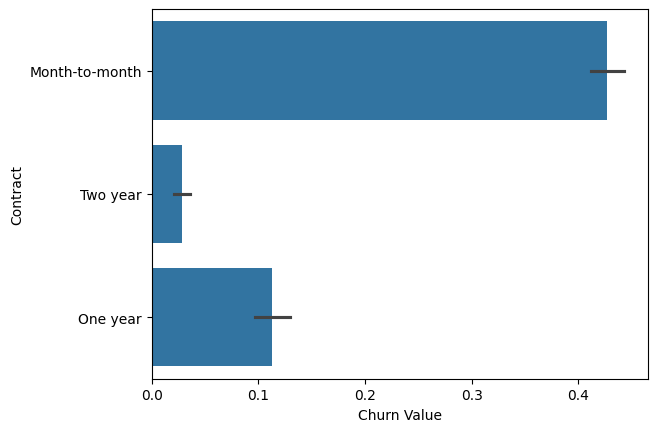

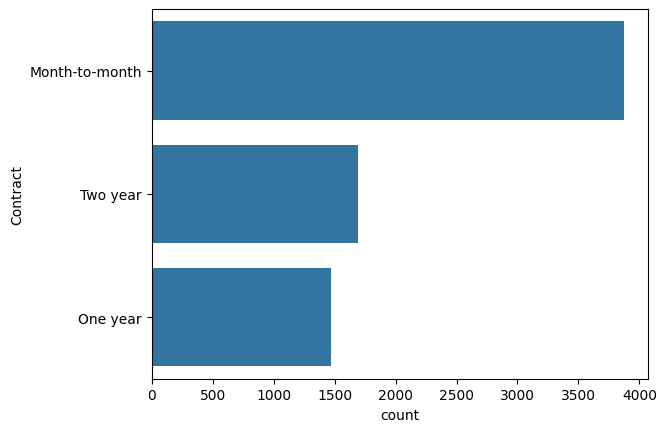

In [88]:
executor(q3)

sns.barplot(df, y="Contract", x='Churn Value')
plt.figure()
sns.countplot(df, y= "Contract")

('High', 0.35477582846003897)
('Low', 0.09800362976406533)
('Medium', 0.2406892718176765)




/tmp/ipykernel_55/35277634.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby("monthly_charges_bin")["Churn Value"].mean())


monthly_charges_bin
Low       0.093226
Medium    0.228504
High      0.356263
Name: Churn Value, dtype: float64

<Axes: xlabel='Churn Value', ylabel='monthly_charges_bin'>

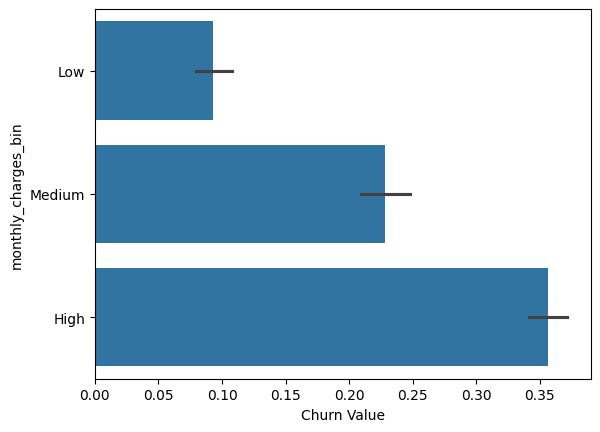

In [77]:
executor(q4)

df["monthly_charges_bin"] = pd.cut(df["Monthly Charges"], bins=[-np.inf, 30-1, 70-1, np.inf], labels="Low, Medium, High".split(", ")) # inclusive right
display(df.groupby("monthly_charges_bin")["Churn Value"].mean())
sns.barplot(df, y="monthly_charges_bin", x="Churn Value")

('Month-to-month', 'Fiber optic', 0.5460526315789473)
('Month-to-month', 'DSL', 0.3221586263286999)
('One year', 'Fiber optic', 0.19294990723562153)
('Month-to-month', 'No', 0.18893129770992367)
('One year', 'DSL', 0.09298245614035087)
('Two year', 'Fiber optic', 0.07226107226107226)
('One year', 'No', 0.024725274725274724)
('Two year', 'DSL', 0.01910828025477707)
('Two year', 'No', 0.007836990595611285)




<Axes: xlabel='Yes', ylabel='Contract'>

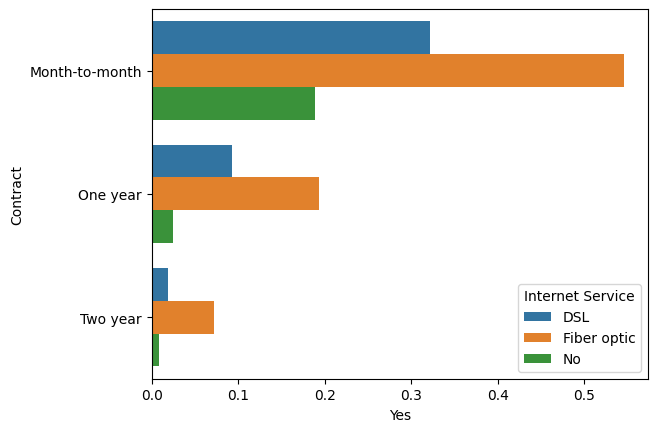

In [65]:
executor(q5)

sns.barplot(pd.crosstab(index=[df["Contract"], df["Internet Service"]], columns=df['Churn Label'], normalize=0).reset_index(), 
            y="Contract", x="Yes", hue="Internet Service")

## Key Insights --- Indeeed ChatGPT
1. **Churn rate is ~26.5%**, indicating a significant portion of customers leave the service.
2. **Tenure is strongly related to churn**
    - Customers with shorter tenure are much more likely to churn --> uhm, fail to get on board 
    - Long-term customers are significantly more stable
3. **Contract type is a major driver**
    - Month-to-month contracts have the highest churn rate; month to month --> low commitment --> easy to leave
    - Long-term contracts reduce churn significantly
4. **Higher monthly charges are associated with higher churn**
    - Customers who churn tend to pay more (monthly)
    - Price sensitivity may be a factor; high charges --> (in case a problem or) perceived low value --> churn 
4. **High-risk customer segment identified**
    - Fiber optic users with month-to-month contracts show the highest churn rate

## Recommendations
- Encourage customers to switch to **long-term contracts** through discounts
- Improve **onboarding experience** for new customers
- Review pricing strategy for **high-charge segments** --> what kind of pricing strategy? ask me not
- Target high-risk segments (fiber + month-to-month) with **retention campaigns** --> is it worth the work?